In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.preprocessing import StandardScaler
def analyzer(max_depth):
    data=pd.read_csv("Social_Network_Ads.csv")
    x=data.iloc[: ,2:4].values
    y=data.iloc[: ,4].values
    # scale features to keep the meshgrid size reasonable
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    clf=DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(x_scaled,y)

    # use a coarser grid (200x200) to avoid huge memory usage
    a = np.linspace(x_scaled[:,0].min()-1, x_scaled[:,0].max()+1, 200)
    b = np.linspace(x_scaled[:,1].min()-1, x_scaled[:,1].max()+1, 200)
    xx, yy = np.meshgrid(a, b)

    input_array = np.c_[xx.ravel(), yy.ravel()]
    labels = clf.predict(input_array)
    plt.contourf(xx, yy, labels.reshape(xx.shape), alpha=0.5)
    plt.scatter(x_scaled[:,0], x_scaled[:,1], c=y, edgecolors='k', marker='o')

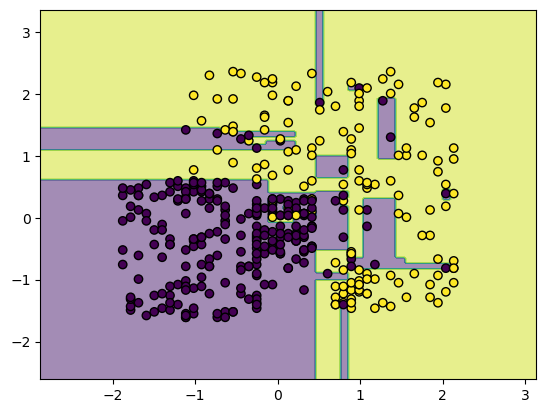

In [9]:
analyzer(max_depth=None)